In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys 

import analysis_utils
sys.path.append("../")

import checkpoint
import generate_data

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Loaded following dataloaders:
val dataloader (n=22,912),
test dataloader (n=22,912)
Loading model that has completed (or started) 20 of 20 epochs
	batch size: 25
	number of steps:146,640
	best val loss achieved: 1.0977
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout
Training information for model trained with 3 study examples:
Best Validation Loss: 1.098
Best Validation Accuracy: 0.427


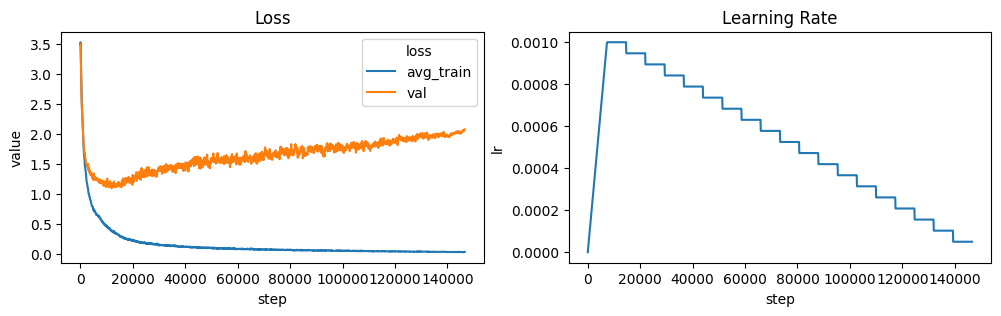

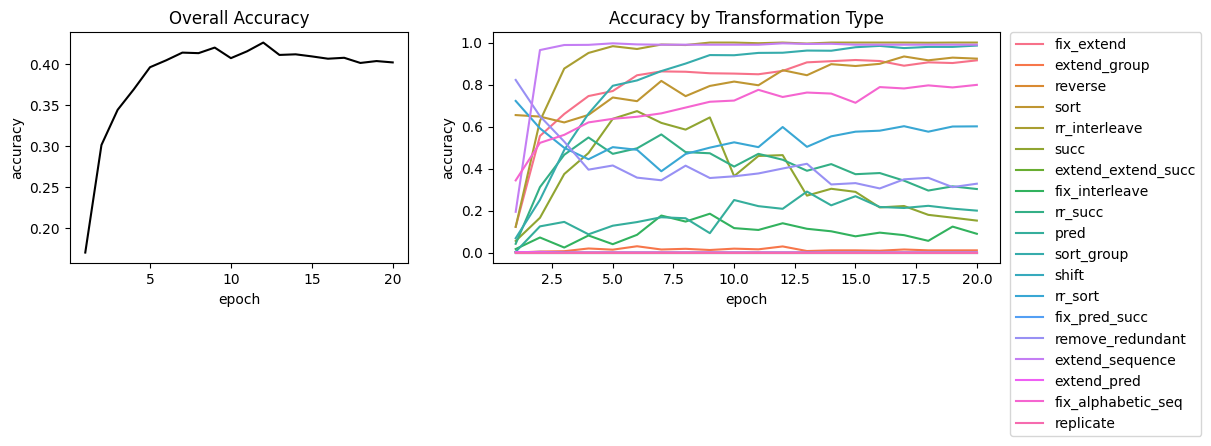

In [32]:
cp = checkpoint.CheckPoint("../models/MLC_dallstudy1_nep20.pt", device=DEVICE)
val, test = cp.load_dataloaders("../data/all_transformations_study1", val_batch_size=1000, use_datasets=["val","test"])
model = cp.load_model()
analysis_utils.training_information(cp, val, "Training information for model trained with 3 study examples:")

Loaded following dataloaders:
val dataloader (n=22,825),
test dataloader (n=22,825)
Loading model that has completed (or started) 20 of 20 epochs
	batch size: 25
	number of steps:146,080
	best val loss achieved: 1.0904
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout
Training information for model trained with 3 study examples:
Best Validation Loss: 1.090
Best Validation Accuracy: 0.372


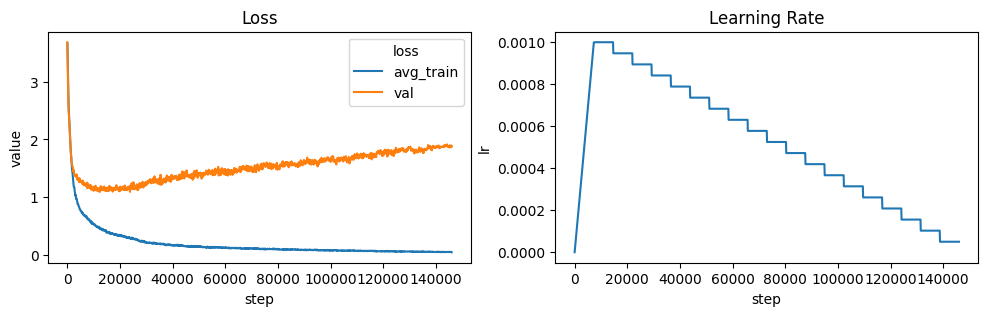

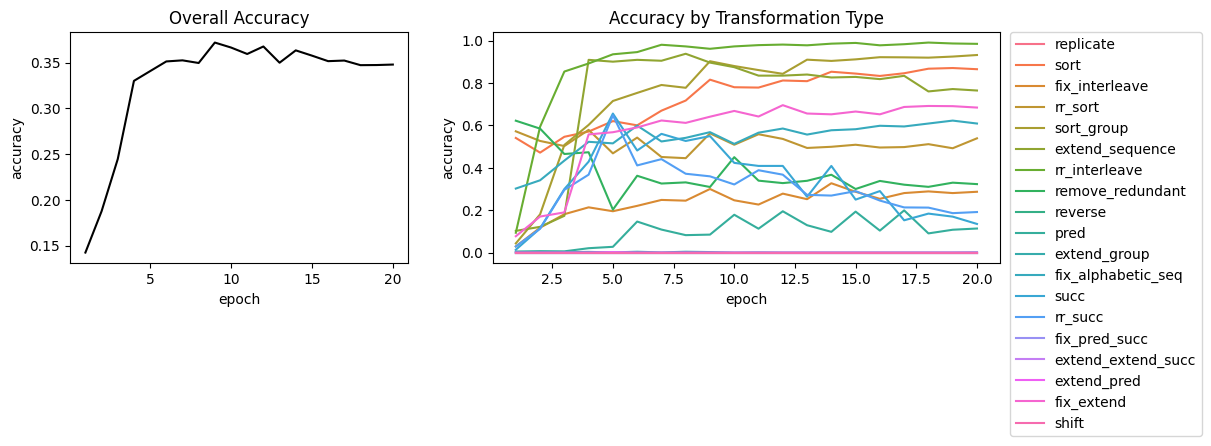

In [33]:
cp = checkpoint.CheckPoint("../models/MLC_dallstudy2_nep20.pt", device=DEVICE)
val, test = cp.load_dataloaders("../data/all_transformations_study2", val_batch_size=1000, use_datasets=["val","test"])
model = cp.load_model()
analysis_utils.training_information(cp, val, "Training information for model trained with 3 study examples:")

Loaded following dataloaders:
val dataloader (n=22,682),
test dataloader (n=22,682)
Loading model that has completed (or started) 20 of 20 epochs
	batch size: 25
	number of steps:145,180
	best val loss achieved: 1.0800
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout
Training information for model trained with 3 study examples:
Best Validation Loss: 1.080
Best Validation Accuracy: 0.420


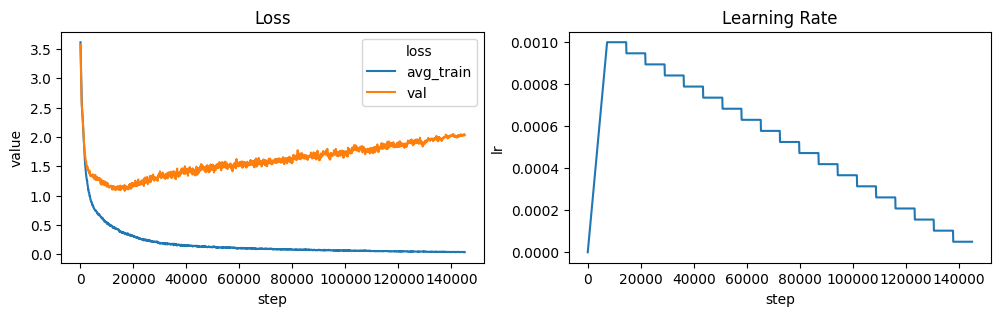

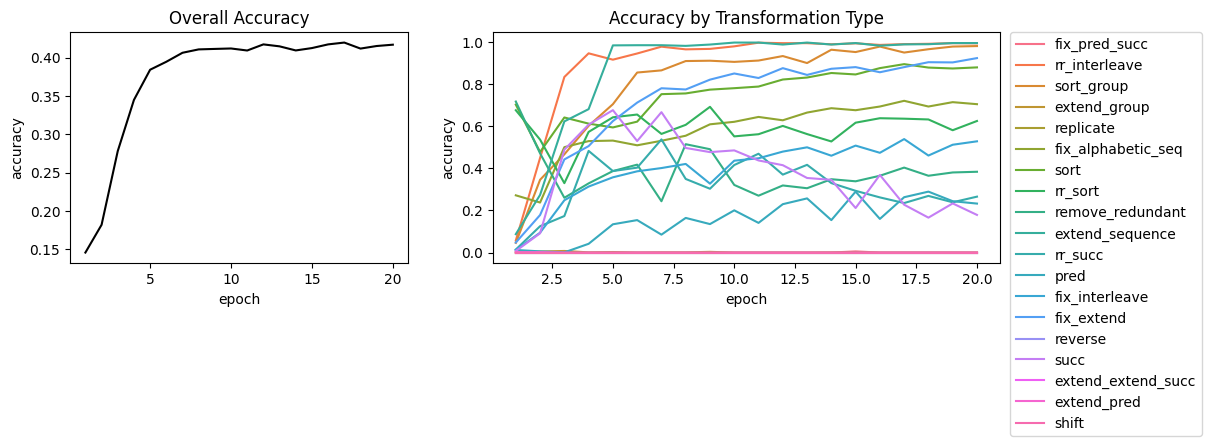

In [35]:
cp = checkpoint.CheckPoint("../models/MLC_dallstudy3_nep20.pt", device=DEVICE)
val, test = cp.load_dataloaders("../data/all_transformations_study3", val_batch_size=1000, use_datasets=["val","test"])
model = cp.load_model()
analysis_utils.training_information(cp, val, "Training information for model trained with 3 study examples:")

Loaded following dataloaders:
val dataloader (n=22,157),
test dataloader (n=22,157)
Loading model that has completed (or started) 20 of 20 epochs
	batch size: 25
	number of steps:141,820
	best val loss achieved: 1.0755
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout
Training information for model trained with 3 study examples:
Best Validation Loss: 1.075
Best Validation Accuracy: 0.421


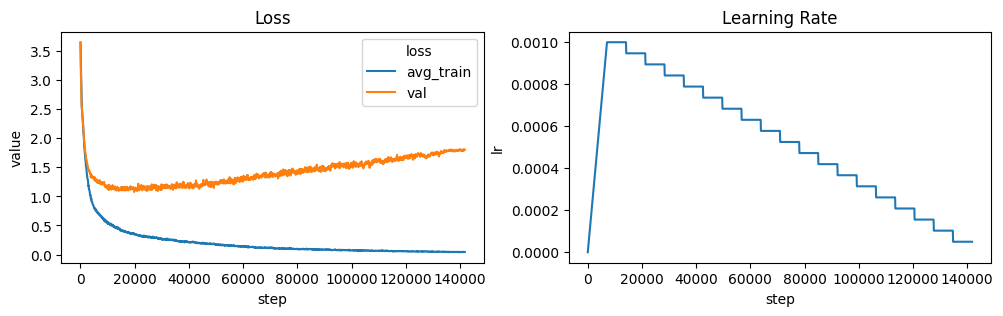

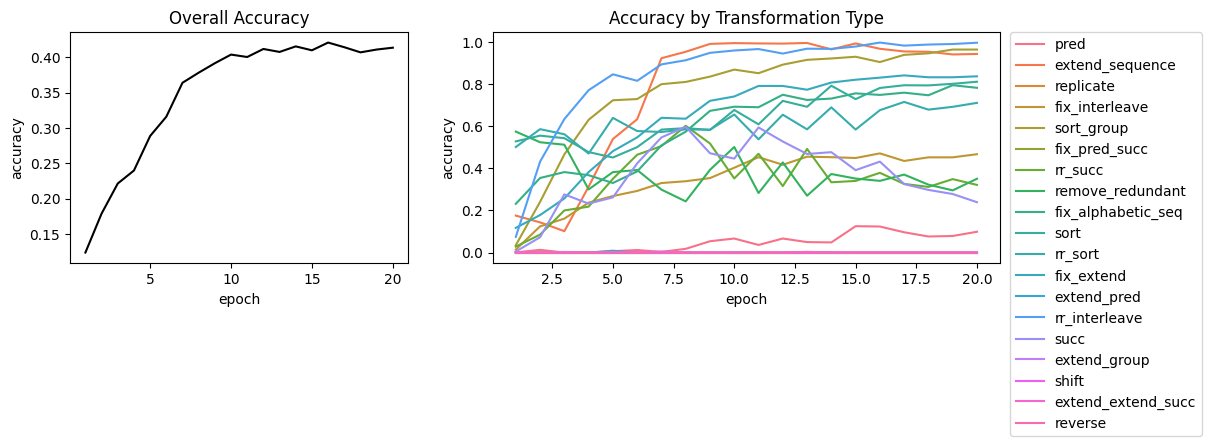

In [34]:
cp = checkpoint.CheckPoint("../models/MLC_dallstudy4_nep20.pt", device=DEVICE)
val, test = cp.load_dataloaders("../data/all_transformations_study4", val_batch_size=1000, use_datasets=["val","test"])
model = cp.load_model()
analysis_utils.training_information(cp, val, "Training information for model trained with 3 study examples:")

### Generalization types

In [ ]:
val_acc = pd.DataFrame(cp.checkpoint["val_accuracy"])
val_acc = pd.melt(val_acc, id_vars=['epoch'], value_vars=val.dataset.transformation_types, var_name="transformation", value_name="accuracy")

In [ ]:
import generate_data

generalization_types = dict()
type_0 = {trans[1].__name__: 0 for trans in list(generate_data.ALL_TRANSFORMATIONS.items())[:10]}
generalization_types.update(type_0)
type_2 = {trans[1].__name__: 2 for trans in list(generate_data.ALL_TRANSFORMATIONS.items())[10:16]}
generalization_types.update(type_2)
type_3 = {trans[1].__name__: 3 for trans in list(generate_data.ALL_TRANSFORMATIONS.items())[16:]}
generalization_types.update(type_3)
for key, value in generalization_types.items():
    print(key, value)
val_acc["generalization_type"] = val_acc["transformation"].apply(lambda x: generalization_types[x])

In [30]:
val_acc["generalization_type"] = val_acc["transformation"].apply(lambda x: generalization_types[x])

In [32]:
val_final_acc = val_acc[val_acc.epoch == val_acc.epoch.max()]

In [36]:
val_final_acc.groupby("generalization_type")["accuracy"].mean()

generalization_type
0    0.563749
2    0.138513
3    0.000000
Name: accuracy, dtype: float64

In [ ]:
#  Transformations present in both data splits
# 1.	Extend Sequence (a b c d -> a b c d e)
# 2.	Successor (a b c d -> a b c e)
# 3.	Predecessor (b c d e -> a c d e)
# 4.	Remove Redundant letter (a b b c d -> a b c d)
# 5.	Fix alphabetic sequence (a b c w e -> a b c d e)
# 6.	Sort (a d c b e -> a b c d e)
# 7.	Sort + Group (aa dd cc bb ee -> aa bb cc dd ee)
# 8.	Remove redundant + Interleave (a x b x b x c x d -> a x b x c x d)
# 9.	Remove Redundant + successor (a b b c d -> a b c e)
# 10.	Fix alphabetic sequence + extend sequence (a b c w -> a b c d e)
#
# Transformations only present in validation/ test splits:
# 11. Remove Redundant + Sort (a d d c b e -> a b c d e)
# 12. Extend Sequence + Predecessor (b c d e -> a c d e f)
# 13. Fix alphabetic sequence + Interleave (a f b f c f w f e -> a f b f c f d f e)
# 14. Extend sequence + Group (aa bb cc dd -> aa bb cc dd ee)
# 15. Extend Sequence + Extend Sequence + Successor (a b c d -> a b c d e g)
# 16. Fix alphabetic Sequence + Predecessor + Successor (a b c w e -> a a c d f)
# 17. Reverse (a b c d -> d c b a)
# 18. Shift (a b c d -> e f g h)
# 19. Replicate (a b c d -> a b c d a b c d)

In [4]:
cp_study1 = checkpoint.CheckPoint("../models/MLC_dallstudy1_nep20.pt", device=DEVICE)
val_acc1 = pd.DataFrame(cp_study1.checkpoint["val_accuracy"])
val_acc1

,epoch,overall,extend_extend_succ,extend_group,extend_pred,extend_sequence,fix_alphabetic_seq,fix_extend,fix_interleave,fix_pred_succ,...,remove_redundant,replicate,reverse,rr_interleave,rr_sort,rr_succ,shift,sort,sort_group,succ
0,1,0.120155,0.001099,0.000000,0.0,0.305616,0.199838,0.149361,0.012759,0.000000,...,0.463415,0.0,0.0,0.100392,0.412510,0.017210,0.0,0.479266,0.038125,0.036048
1,2,0.282472,0.000000,0.001622,0.0,0.924872,0.398050,0.369808,0.032695,0.000000,...,0.515808,0.0,0.0,0.635294,0.509105,0.347826,0.0,0.519936,0.325655,0.440587
2,3,0.301065,0.000000,0.004866,0.0,0.905908,0.464663,0.455272,0.091707,0.000000,...,0.338753,0.0,0.0,0.814902,0.391132,0.500000,0.0,0.543062,0.373312,0.461949
3,4,0.350122,0.000000,0.011354,0.0,0.913931,0.469537,0.533546,0.066188,0.000000,...,0.302620,0.0,0.0,0.919216,0.428345,0.642210,0.0,0.580542,0.658459,0.670895
4,5,0.337116,0.000000,0.005677,0.0,0.938731,0.452478,0.514377,0.091707,0.000000,...,0.348690,0.0,0.0,0.920000,0.483769,0.493659,0.0,0.546252,0.701350,0.531375
5,6,0.356756,0.000000,0.012165,0.0,0.943107,0.563769,0.555911,0.129984,0.000000,...,0.499548,0.0,0.0,0.933333,0.492478,0.374094,0.0,0.627592,0.669579,0.518024
6,7,0.378099,0.000000,0.017843,0.0,0.932896,0.546710,0.611022,0.150718,0.008354,...,0.551942,0.0,0.0,0.970196,0.574822,0.248188,0.0,0.723285,0.848292,0.534045
7,8,0.362387,0.000000,0.011354,0.0,0.913202,0.497157,0.556709,0.122010,0.000000,...,0.354110,0.0,0.0,0.980392,0.431512,0.489130,0.0,0.649123,0.868944,0.541389
8,9,0.374214,0.000000,0.007299,0.0,0.900073,0.533712,0.569489,0.196970,0.000000,...,0.329720,0.0,0.0,0.979608,0.521774,0.468297,0.0,0.685008,0.866561,0.534045
9,10,0.369981,0.000000,0.003244,0.0,0.923414,0.545085,0.592652,0.137959,0.000000,...,0.316170,0.0,0.0,0.990588,0.429929,0.554348,0.0,0.687400,0.896743,0.433912


### Comparison number of study examples

In [25]:
cp_study1 = checkpoint.CheckPoint("../models/MLC_dallstudy1_nep20.pt", device=DEVICE)
val_acc1 = pd.DataFrame(cp_study1.checkpoint["val_accuracy"])
val_acc1 = pd.melt(val_acc1, id_vars=['epoch'], value_vars=["in","out-of"], var_name="distribution", value_name="accuracy")
val_acc1["study_examples"] = 1

cp_study2 = checkpoint.CheckPoint("../models/MLC_dallstudy2_nep20.pt", device=DEVICE)
val_acc2 = pd.DataFrame(cp_study2.checkpoint["val_accuracy"])
val_acc2 = pd.melt(val_acc2, id_vars=['epoch'], value_vars=["in","out-of"], var_name="distribution", value_name="accuracy")
val_acc2["study_examples"] = 2

cp_study3 = checkpoint.CheckPoint("../models/MLC_dallstudy3_nep20.pt", device=DEVICE)
val_acc3 = pd.DataFrame(cp_study3.checkpoint["val_accuracy"])
val_acc3 = pd.melt(val_acc3, id_vars=['epoch'], value_vars=["in","out-of"], var_name="distribution", value_name="accuracy")
val_acc3["study_examples"] = 3

cp_study4 = checkpoint.CheckPoint("../models/MLC_dallstudy4_nep20.pt", device=DEVICE)
val_acc4 = pd.DataFrame(cp_study4.checkpoint["val_accuracy"])
val_acc4 = pd.melt(val_acc4, id_vars=['epoch'], value_vars=["in","out-of"], var_name="distribution", value_name="accuracy")
val_acc4["study_examples"] = 4

In [26]:
val_acc_by_nstudy = pd.concat([val_acc1,val_acc2,val_acc3,val_acc4])
val_acc_by_nstudy.head()

,epoch,distribution,accuracy,study_examples
0,1,in,0.233793,1
1,2,in,0.479949,1
2,3,in,0.572515,1
3,4,in,0.616659,1
4,5,in,0.664606,1


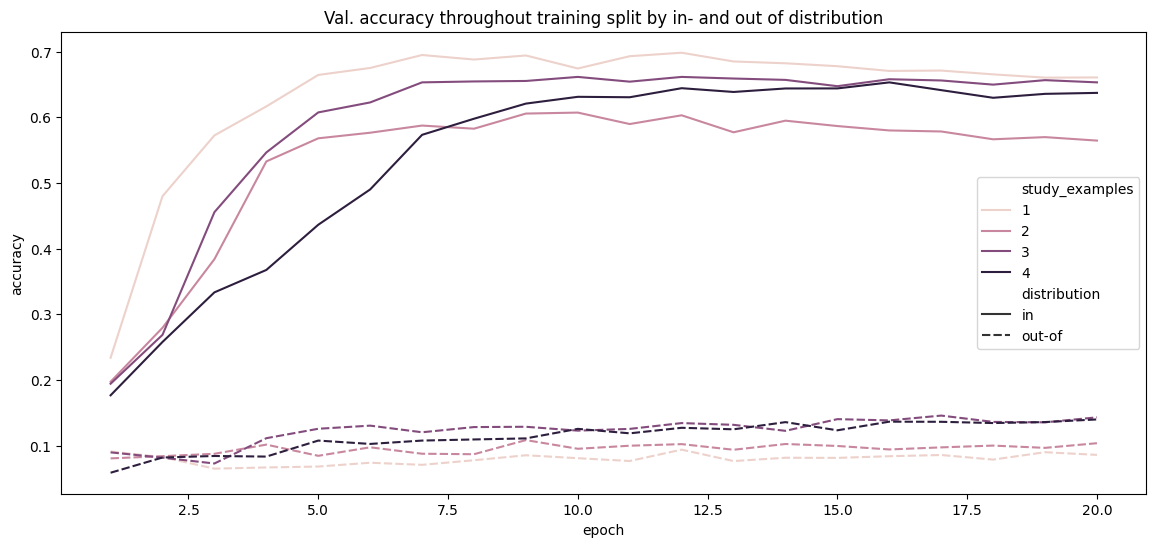

In [ ]:
fig, ax = plt.subplots(figsize=(14,6))
_ = sns.lineplot(data=val_acc_by_nstudy, x="epoch", y="accuracy", hue="study_examples", style="distribution", ax=ax)
_ = ax.set_title("Val. accuracy throughout training split by in- and out of distribution")

In [21]:
cp_study1 = checkpoint.CheckPoint("../models/MLC_dallstudy1_nep20.pt", device=DEVICE)
val_acc1 = pd.DataFrame(cp_study1.checkpoint["val_accuracy"])
val_acc1 = pd.melt(val_acc1, id_vars=['epoch'], value_vars=["overall"], var_name="overall", value_name="accuracy")
val_acc1["study_examples"] = 1

cp_study2 = checkpoint.CheckPoint("../models/MLC_dallstudy2_nep20.pt", device=DEVICE)
val_acc2 = pd.DataFrame(cp_study2.checkpoint["val_accuracy"])
val_acc2 = pd.melt(val_acc2, id_vars=['epoch'], value_vars=["overall"], var_name="overall", value_name="accuracy")
val_acc2["study_examples"] = 2

cp_study3 = checkpoint.CheckPoint("../models/MLC_dallstudy3_nep20.pt", device=DEVICE)
val_acc3 = pd.DataFrame(cp_study3.checkpoint["val_accuracy"])
val_acc3 = pd.melt(val_acc3, id_vars=['epoch'], value_vars=["overall"], var_name="overall", value_name="accuracy")
val_acc3["study_examples"] = 3

cp_study4 = checkpoint.CheckPoint("../models/MLC_dallstudy4_nep20.pt", device=DEVICE)
val_acc4 = pd.DataFrame(cp_study4.checkpoint["val_accuracy"])
val_acc4 = pd.melt(val_acc4, id_vars=['epoch'], value_vars=["overall"], var_name="overall", value_name="accuracy")
val_acc4["study_examples"] = 4

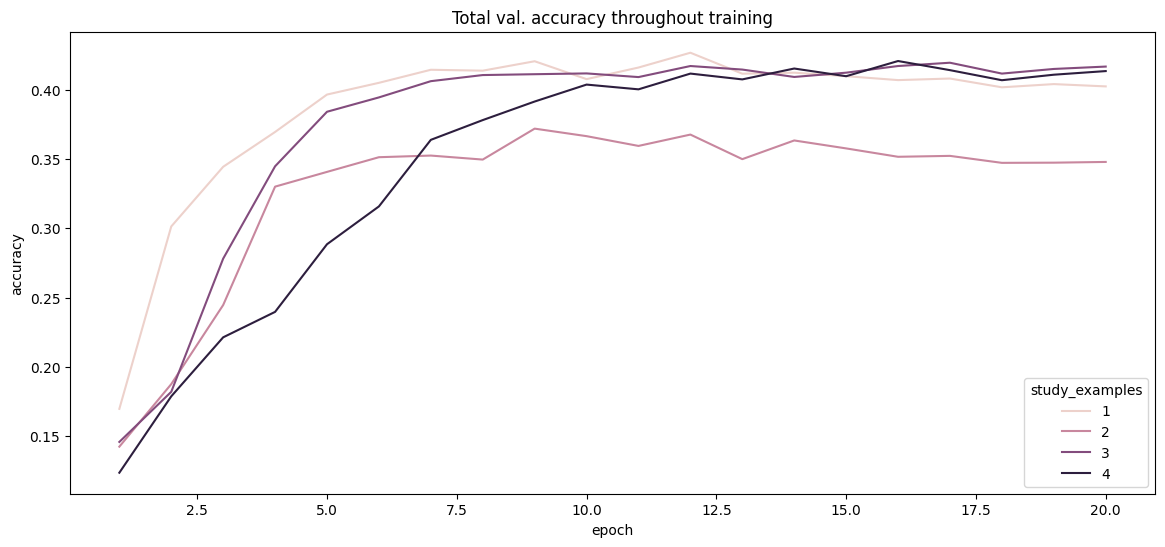

In [24]:
val_acc_by_nstudy_overall = pd.concat([val_acc1,val_acc2,val_acc3,val_acc4])
fig, ax = plt.subplots(figsize=(14,6))
_ = sns.lineplot(data=val_acc_by_nstudy_overall, x="epoch", y="accuracy", hue="study_examples", ax=ax)
_ = ax.legend(title="study_examples", loc="lower right") 
_ = ax.set_title("Total val. accuracy throughout training")

### Training with all transformations

Loaded following dataloaders:
val dataloader (n=42,656)
Loading model that has completed (or started) 20 of 20 epochs
	batch size: 25
	number of steps:273,020
	best val loss achieved: 0.1411
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout
Training information:
Best Validation Loss: 0.141
Best Validation Accuracy: 0.576


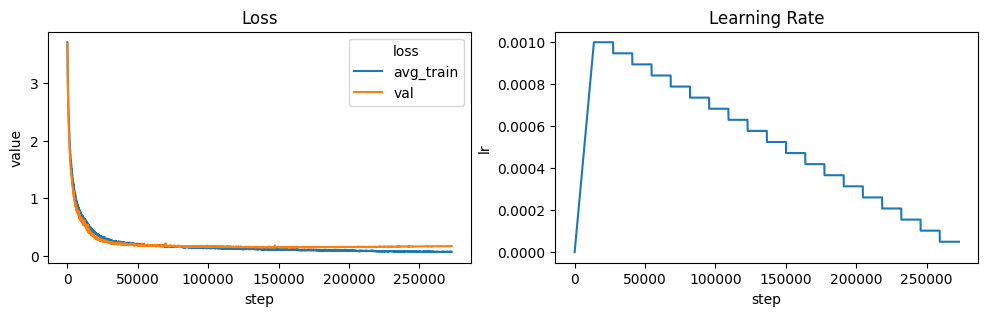

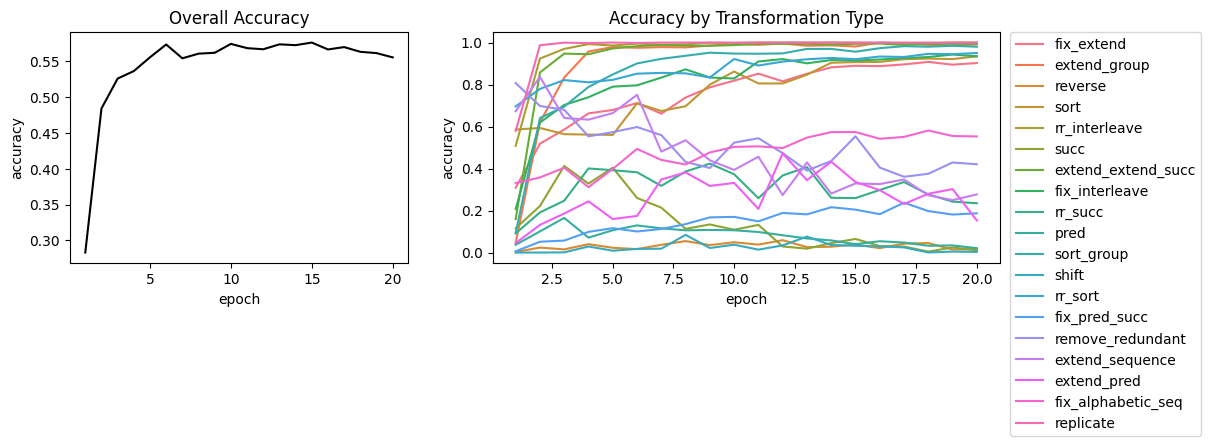

In [18]:
cp_tr_all_study1 = checkpoint.CheckPoint("../models/MLC_all_trans_all_train_study1_nep20.pt", device=DEVICE)
val = cp_tr_all_study1.load_dataloaders("../data/all_transformations_all_training", use_datasets=["val"])[0]
model = cp_tr_all_study1.load_model()
analysis_utils.training_information(cp_tr_all_study1, val)

In [17]:
val_acc = pd.DataFrame(cp_tr_all_study1.checkpoint["val_accuracy"])
val_acc = pd.melt(val_acc, id_vars=['epoch'], value_vars=val.dataset.transformation_types, var_name="transformation", value_name="accuracy")
val_acc[val_acc.epoch==20].sort_values("accuracy")

,epoch,transformation,accuracy
239,20,shift,0.003086
119,20,succ,0.010460
59,20,reverse,0.016337
199,20,pred,0.020842
339,20,extend_pred,0.152778
279,20,fix_pred_succ,0.186924
179,20,rr_succ,0.234804
319,20,extend_sequence,0.277016
299,20,remove_redundant,0.420533
359,20,fix_alphabetic_seq,0.552891


In [ ]:
analysis_utils.training_information(cp, val, "Training information for model trained with 3 study examples:")

,epoch,step,lr,avg_train_loss,val_loss
0,1,1,1.000000e-07,3.707117,3.682917
1,1,25,1.858066e-06,3.655315,3.651938
2,1,100,7.352022e-06,3.510921,3.338864
3,1,200,1.467730e-05,3.273587,3.159116
4,1,300,2.200257e-05,3.136479,2.977559
...,...,...,...,...,...
2727,20,272600,5.000000e-05,0.070412,0.165311
2728,20,272700,5.000000e-05,0.064650,0.165479
2729,20,272800,5.000000e-05,0.066182,0.165395
2730,20,272900,5.000000e-05,0.066505,0.165661


In [19]:
pred_data = analysis_utils.predict_dataset(val, model)

Predicting:   0%|          | 0/1707 [00:00<?, ?it/s]c:\Users\phili\anaconda3\envs\mlc-ls\Lib\site-packages\torch\nn\modules\transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(
Predicting: 100%|██████████| 1707/1707 [19:23<00:00,  1.47it/s]


In [21]:
# split into correct and incorrect samples
correct_pred = pred_data[pred_data["correct"]==True]
incorrect_pred = pred_data[pred_data["correct"]==False]

In [ ]:
print(incorrect_pred.groupby("transformation")["alternate_rule"].value_counts())

transformation      alternate_rule
extend_extend_succ  na                  10
extend_group        na                  19
extend_pred         na                1525
extend_sequence     na                1791
fix_alphabetic_seq  na                 909
                    pred               136
fix_extend          na                 222
fix_interleave      na                 154
fix_pred_succ       na                1706
                    pred                48
                    succ                10
pred                na                1720
                    succ               582
remove_redundant    na                1171
reverse             pred               899
                    na                 762
                    succ               628
rr_sort             na                 119
rr_succ             na                1561
shift               pred               688
                    na                 661
                    succ               589
sort               

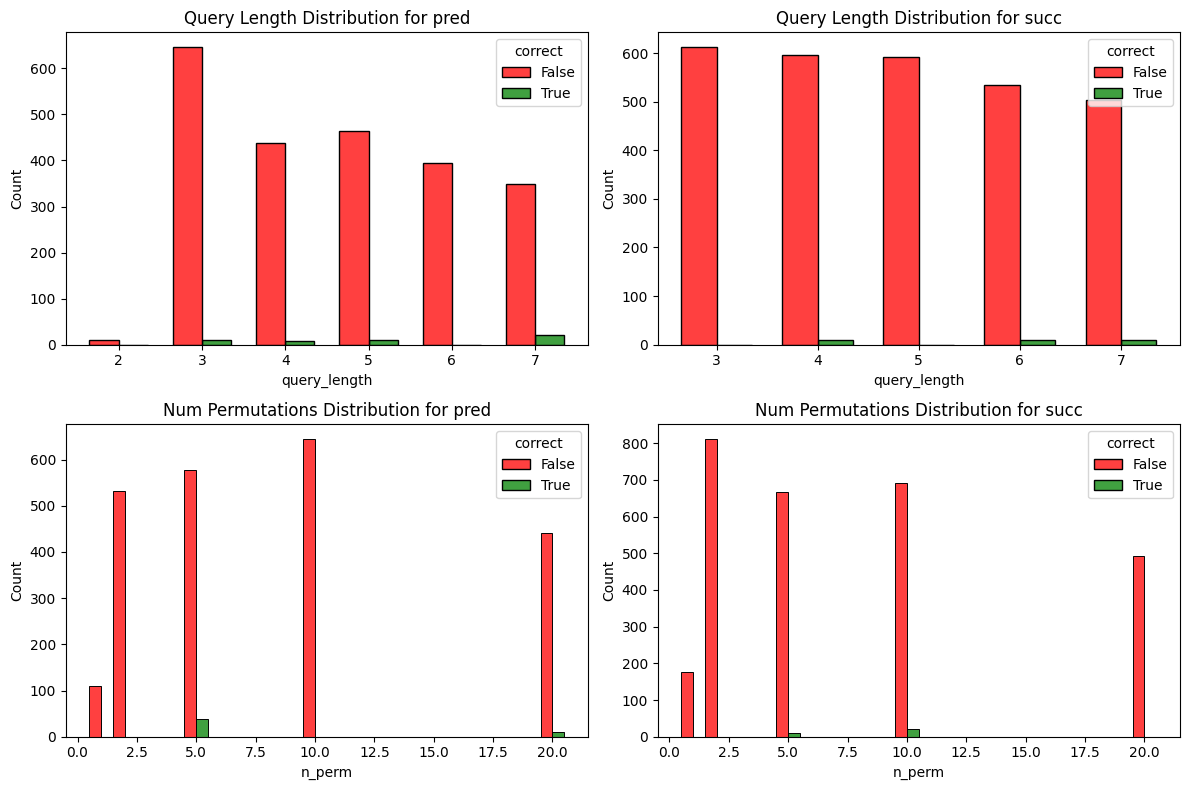

In [23]:
palette = {True: "green", False: "red"}
fig, ax = plt.subplots(2,2, figsize=(12,8))
_ = sns.histplot(pred_data[pred_data.transformation.isin(["pred"])], x="query_length", hue="correct", discrete=True, multiple="dodge", shrink=.7, palette=palette, ax=ax[0,0])
_ = ax[0,0].set_title("Query Length Distribution for pred")
_ = sns.histplot(pred_data[pred_data.transformation.isin(["succ"])], x="query_length", hue="correct", discrete=True, multiple="dodge", shrink=.7, palette=palette, ax=ax[0,1])
_ = ax[0,1].set_title("Query Length Distribution for succ")
_ = sns.histplot(pred_data[pred_data.transformation.isin(["pred"])], x="n_perm", hue="correct", discrete=True, multiple="dodge", palette=palette, ax=ax[1,0])
_ = ax[1,0].set_title("Num Permutations Distribution for pred")
_ = sns.histplot(pred_data[pred_data.transformation.isin(["succ"])], x="n_perm", hue="correct", discrete=True, multiple="dodge", palette=palette, ax=ax[1,1])
_ = fig.tight_layout(h_pad=1, w_pad=1)
_ = ax[1,1].set_title("Num Permutations Distribution for succ")

In [34]:
acc_by_len = pred_data.groupby("query_length")["correct"].mean()
acc_by_len

query_length
2     0.238095
3     0.387144
4     0.430533
5     0.465848
6     0.501498
7     0.531751
8     0.693625
9     0.979375
10    0.980176
11    0.970149
12    0.968202
13    0.987196
14    0.993119
15    1.000000
18    0.998000
21    1.000000
Name: correct, dtype: float64

In [44]:
trans_by_len = pred_data.groupby("query_length")["transformation"].unique()
trans_by_len

query_length
2       [reverse, sort, replicate, pred, fix_pred_succ]
3     [fix_extend, succ, shift, sort, reverse, pred,...
4     [reverse, sort, fix_extend, extend_extend_succ...
5     [succ, fix_extend, pred, rr_sort, extend_pred,...
6     [succ, rr_succ, fix_pred_succ, remove_redundan...
7     [rr_succ, rr_sort, succ, extend_sequence, repl...
8     [rr_succ, remove_redundant, extend_group, rr_s...
9     [fix_interleave, rr_interleave, sort_group, ex...
10                           [sort_group, extend_group]
11                      [rr_interleave, fix_interleave]
12                           [sort_group, extend_group]
13                      [rr_interleave, fix_interleave]
14                           [extend_group, sort_group]
15            [rr_interleave, sort_group, extend_group]
18                           [sort_group, extend_group]
21                           [extend_group, sort_group]
Name: transformation, dtype: object

In [36]:
for qlen, acc, transformations in zip(trans_by_len.index, acc_by_len, trans_by_len.values):
    print(f"Length={qlen}({acc:.2f}): {','.join(transformations)}")

Length=2(0.24): reverse,sort,replicate,pred,fix_pred_succ
Length=3(0.39): fix_extend,succ,shift,sort,reverse,pred,replicate,extend_sequence,fix_alphabetic_seq,fix_pred_succ,extend_pred,extend_extend_succ,fix_interleave,rr_sort
Length=4(0.43): reverse,sort,fix_extend,extend_extend_succ,rr_succ,shift,pred,sort_group,rr_sort,fix_alphabetic_seq,replicate,extend_sequence,remove_redundant,extend_pred,fix_pred_succ,succ
Length=5(0.47): succ,fix_extend,pred,rr_sort,extend_pred,sort,remove_redundant,extend_sequence,shift,reverse,replicate,fix_alphabetic_seq,rr_succ,fix_pred_succ,fix_interleave,rr_interleave,extend_extend_succ
Length=6(0.50): succ,rr_succ,fix_pred_succ,remove_redundant,rr_sort,sort,fix_extend,reverse,extend_extend_succ,sort_group,extend_sequence,extend_group,pred,replicate,fix_alphabetic_seq,shift,extend_pred
Length=7(0.53): rr_succ,rr_sort,succ,extend_sequence,replicate,reverse,rr_interleave,shift,extend_extend_succ,fix_pred_succ,remove_redundant,fix_interleave,pred,extend_pred

### Different hyperparameters for training on all transformations

In [50]:
cp_bs64 = checkpoint.CheckPoint("../models/MLC_all_trans_all_train_study1_nep20_bs64.pt", device=DEVICE)
val = cp_bs64.load_dataloaders("../data/all_transformations_all_training", val_batch_size= 1000, use_datasets=["val"])[0]
model = cp_bs64.load_model()

Loaded following dataloaders:
val dataloader (n=42,656)
Loading model that has completed (or started) 20 of 20 epochs
	batch size: 64
	number of steps:106,660
	best val loss achieved: 0.1570
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout


Training information:
Best Validation Loss: 0.157
Best Validation Accuracy: 0.555


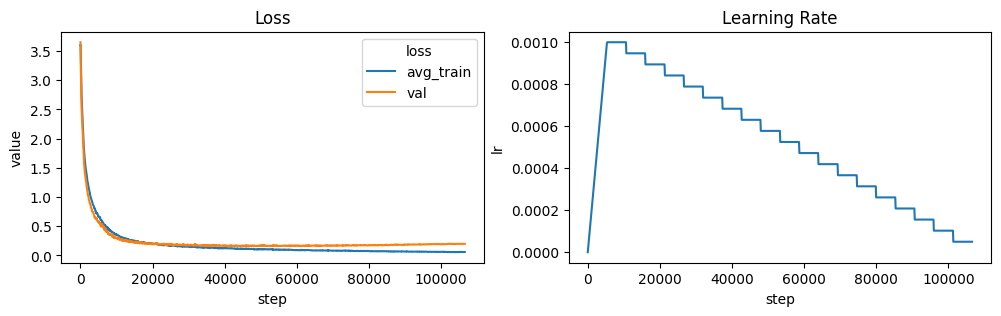

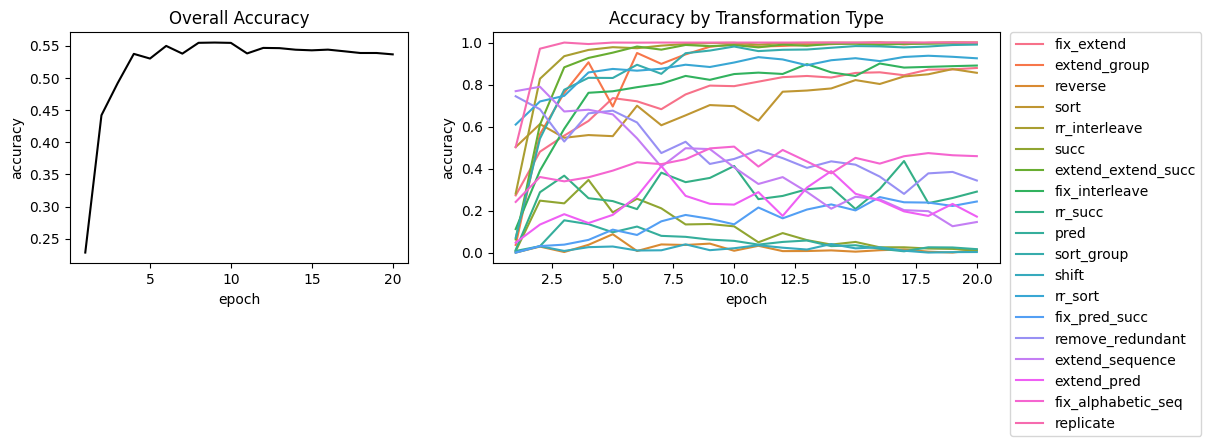

In [51]:
analysis_utils.training_information(cp_bs64, val)

In [53]:
cp_larger = checkpoint.CheckPoint("../models/MLC_all_trans_all_train_study1_nep20_largernet.pt", device=DEVICE)
cp_low_lr = checkpoint.CheckPoint("../models/MLC_all_trans_all_train_study1_nep20_lr0_0005.pt", device=DEVICE)
cp_s4 = checkpoint.CheckPoint("../models/MLC_all_trans_all_train_study4_nep20.pt", device=DEVICE)


In [57]:
cps = {
    "batch size 64": cp_bs64,
    "larger network": cp_larger,
    "lower learning rate": cp_low_lr,
    "4 study examples": cp_s4
}
for key, cp in cps.items():
    print(f"{key}, best val loss: {cp.checkpoint["best_val_loss"]:.4f}")

batch size 64, best val loss: 0.1570
larger network, best val loss: 0.2262
lower learning rate, best val loss: 0.1690
4 study examples, best val loss: 0.1711


In [59]:
for key, cp in cps.items():
    print(f"{key}:")
    val_acc = pd.DataFrame(cp.checkpoint["val_accuracy"])
    val_acc = pd.melt(val_acc, id_vars=['epoch'], value_vars=val.dataset.transformation_types, var_name="transformation", value_name="accuracy")
    print(val_acc[val_acc.epoch==20].sort_values("accuracy"))

batch size 64:
     epoch      transformation  accuracy
239     20               shift  0.002572
119     20                succ  0.009414
59      20             reverse  0.012898
199     20                pred  0.016163
319     20     extend_sequence  0.145565
339     20         extend_pred  0.171111
279     20       fix_pred_succ  0.243094
179     20             rr_succ  0.290196
299     20    remove_redundant  0.343040
359     20  fix_alphabetic_seq  0.459101
79      20                sort  0.855907
19      20          fix_extend  0.878934
159     20      fix_interleave  0.890579
259     20             rr_sort  0.925073
219     20          sort_group  0.990352
139     20  extend_extend_succ  0.994279
99      20       rr_interleave  0.999185
39      20        extend_group  1.000000
379     20           replicate  1.000000
larger network:
Empty DataFrame
Columns: [epoch, transformation, accuracy]
Index: []
lower learning rate:
     epoch      transformation  accuracy
239     20        

In [60]:
train = cp_bs64.load_dataloaders("../data/all_transformations_all_training", val_batch_size= 1000, use_datasets=["train"])[0]

Loaded following dataloaders:
train dataloader (n=341,251)


In [70]:
item = train.dataset[1]
print(f"Item of transformation '{item["transformation"]}':")
query= " ".join(item["xq"])
study = item["study"]
alphabet = item["alphabet"]
print(f"Inputs:\n\t{alphabet=}\n\t{study=}\n\t{query=}")
print(f"Concatenated into a context string:\n\t{", ".join(item["xq_context"])}")
print(f"Encoded into a tensor of integers:\n\t{item["xq_context_tensor"]}")

Item of transformation 'pred':
Inputs:
	alphabet='a b c u e v g h d k i l m j r p q o s t f n w x y z'
	study='l m j r p > i m j r p'
	query='o s t f n w x'
Concatenated into a context string:
	a, b, c, u, e, v, g, h, d, k, i, l, m, j, r, p, q, o, s, t, f, n, w, x, y, z, SOS, l, m, j, r, p, IO, i, m, j, r, p, SOS, o, s, t, f, n, w, x
Encoded into a tensor of integers:
	tensor([ 0,  1,  2, 20,  4, 21,  6,  7,  3, 10,  8, 11, 12,  9, 17, 15, 16, 14,
        18, 19,  5, 13, 22, 23, 24, 25, 26, 11, 12,  9, 17, 15, 29,  8, 12,  9,
        17, 15, 26, 14, 18, 19,  5, 13, 22, 23, 27])


In [71]:
model64 = cp_bs64.load_model()
pred_data = analysis_utils.predict_dataset(val, model)

Loading model that has completed (or started) 20 of 20 epochs
	batch size: 64
	number of steps:106,660
	best val loss achieved: 0.1570
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout


Predicting: 100%|██████████| 667/667 [19:06<00:00,  1.72s/it]


In [79]:
pred_data.loc[:, ["alphabet","xq","xq_context"]]

,alphabet,xq,xq_context
0,a b c u e v g h d k i l m j r p q o s t f n w ...,"[h, d, c]","[a, b, c, u, e, v, g, h, d, k, i, l, m, j, r, ..."
1,a s r d u f g p i j k l m n o h q b c t z e w ...,"[d, d, d, u, u, u, f, f, f, g, g, g, p, p, p, ...","[a, s, r, d, u, f, g, p, i, j, k, l, m, n, o, ..."
2,u n c d a o g h x j b l m k i p q r s t f v w ...,"[f, v, w, e]","[u, n, c, d, a, o, g, h, x, j, b, l, m, k, i, ..."
3,a b c d e f g h i j k l m n o p q r s t u v w ...,"[s, q, r, p]","[a, b, c, d, e, f, g, h, i, j, k, l, m, n, o, ..."
4,a e c h x l g r q y k t f n d j o i w u v b m ...,"[m, x, l, g]","[a, e, c, h, x, l, g, r, q, y, k, t, f, n, d, ..."
...,...,...,...
42651,a b g d e f s h i j w l m n o p q r k t u v c ...,"[n, o, p, q]","[a, b, g, d, e, f, s, h, i, j, w, l, m, n, o, ..."
42652,m r j k g f q n i b h a w d o p v x s l c e y ...,"[c, k, g, f, q, n, i]","[m, r, j, k, g, f, q, n, i, b, h, a, w, d, o, ..."
42653,a s r d u f g p i j k l m n o h q b c t z e w ...,"[g, p, d]","[a, s, r, d, u, f, g, p, i, j, k, l, m, n, o, ..."
42654,a b c d g f e h i j k l m n o p q r s t u v w ...,"[t, t, u, u, v, v, w, w, x, x]","[a, b, c, d, g, f, e, h, i, j, k, l, m, n, o, ..."


### Improved parameters
- `lr` = 0.0005
- `batch_size` = 64
- `dropout` = 0.2

In [2]:
cp = checkpoint.CheckPoint("../models/MLC_all_trans_study1_nep20_lr0_0005_bs64_dr0_2_io.pt", device=DEVICE)
model = cp.load_model()
val = cp.load_dataloaders("../data/all_transformations_study1", use_datasets=["val"])[0]

Loading model that has completed (or started) 20 of 20 epochs
	batch size: 64
	number of steps:57,280
	best val loss achieved: 1.0405
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.2 dropout
Loaded following dataloaders:
val dataloader (n=22,912)


Training information:
Best Validation Loss: 1.041
Best Validation Accuracy: 0.394


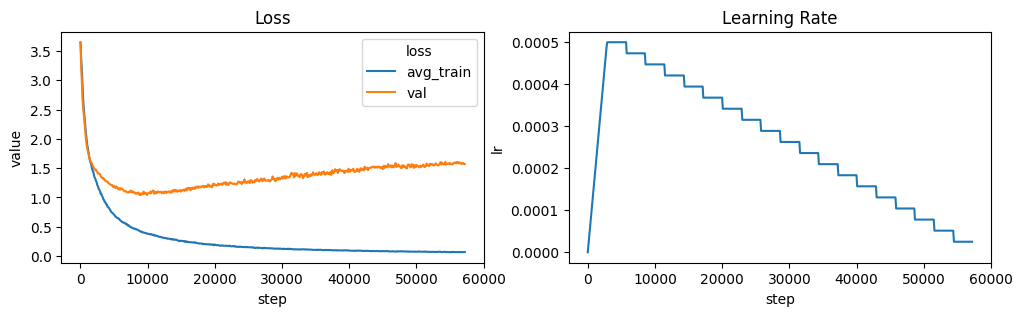

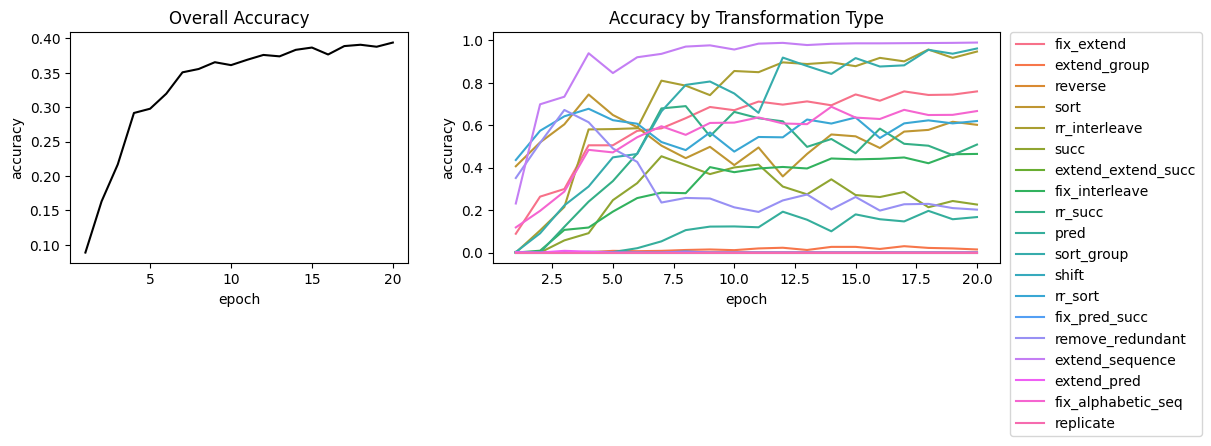

In [3]:
analysis_utils.training_information(cp, val)

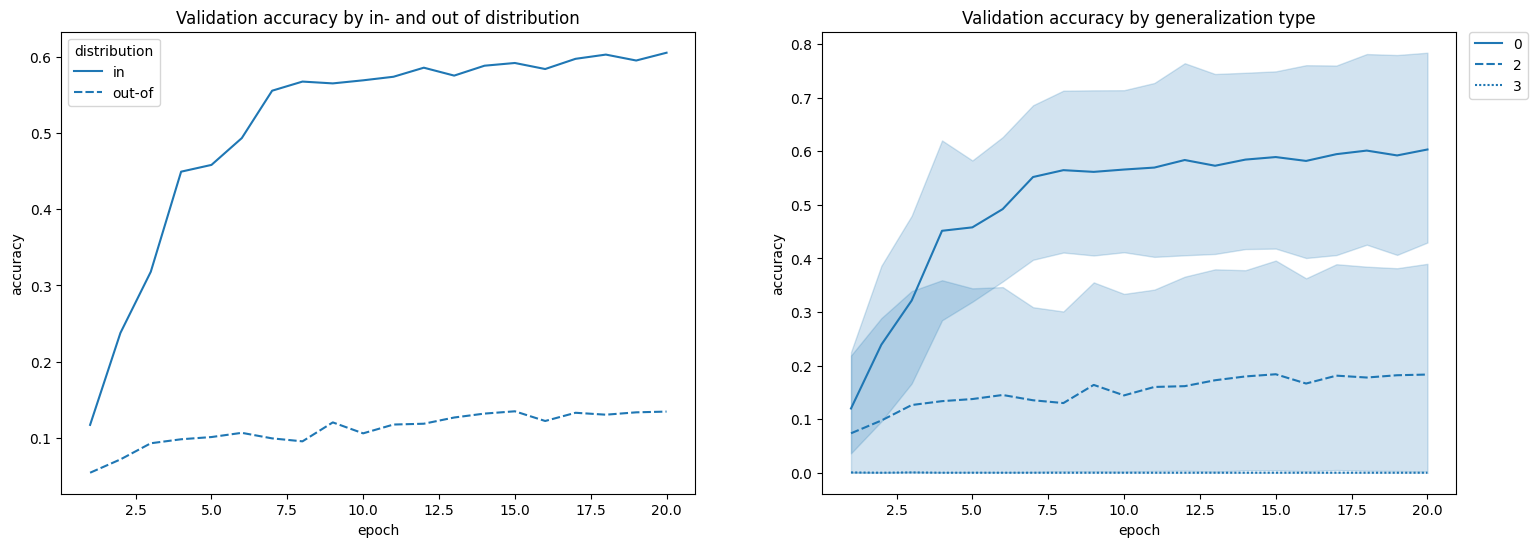

In [16]:
val_acc = pd.DataFrame(cp.checkpoint["val_accuracy"])
val_acc_by_dist = pd.melt(val_acc, id_vars=['epoch'], value_vars=["in","out-of"], var_name="distribution", value_name="accuracy")

fig, ax = plt.subplots(1, 2, figsize=(18,6))
_ = sns.lineplot(data=val_acc_by_dist, x="epoch", y="accuracy", style="distribution", ax=ax[0])
_ = ax[0].set_title("Validation accuracy by in- and out of distribution")

# calc generalization types:
val_acc_by_gen = pd.melt(val_acc, id_vars=['epoch'], value_vars=val.dataset.transformation_types, var_name="transformation", value_name="accuracy")
val_acc_by_gen["generalization"] = val_acc_by_gen.transformation.apply(lambda x: generate_data.STD_GENERALIZATION_TYPES[x])
val_acc_by_gen.groupby("generalization")
_ = sns.lineplot(data=val_acc_by_gen, x="epoch", y="accuracy", style="generalization", ax=ax[1])
_ = ax[1].set_title("Validation accuracy by generalization type")
ax[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

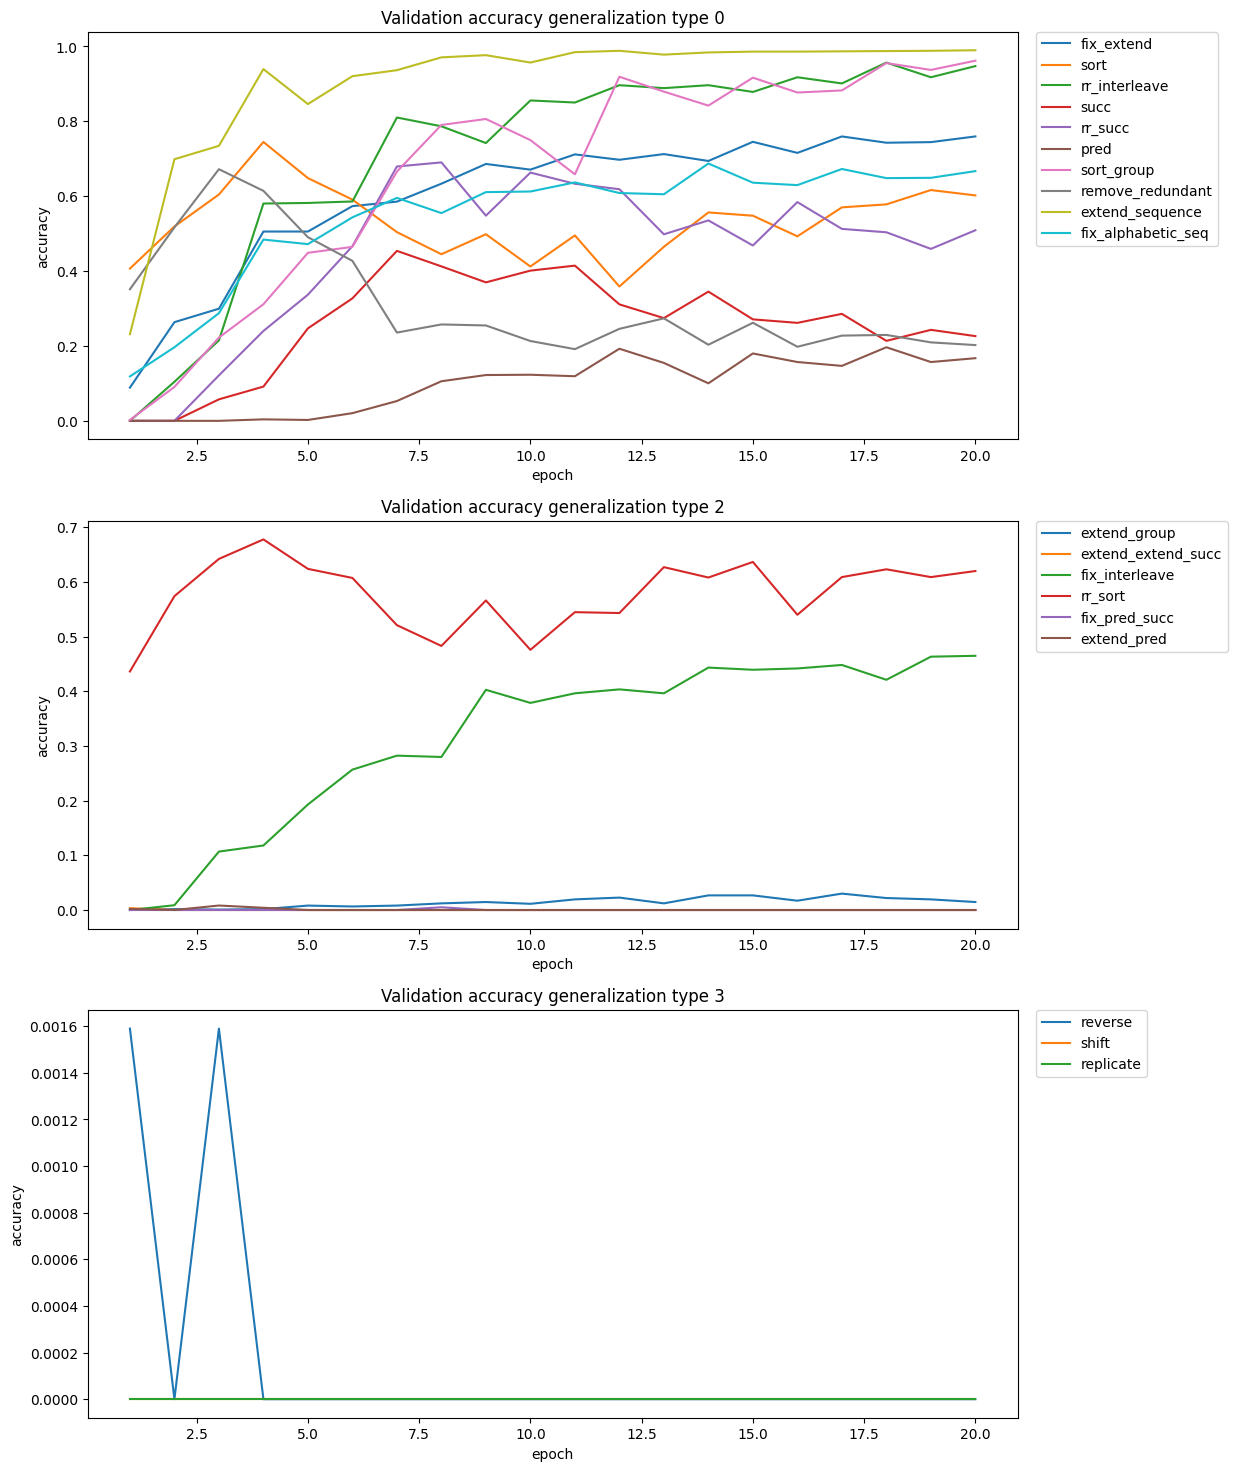

In [18]:
fig, ax = plt.subplots(3, 1, figsize=(12,18))
for i, gen_type in enumerate([0,2,3]):
    _ = sns.lineplot(data=val_acc_by_gen[val_acc_by_gen.generalization==gen_type], x="epoch", y="accuracy", hue="transformation", ax=ax[i])
    _ = ax[i].set_title(f"Validation accuracy generalization type {gen_type}")
    _ = ax[i].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)